In [342]:
import json
import numpy as np
import pandas as pd
import talib
import plotly.graph_objects as go
import plotly.subplots as sub
import yfinance

pd.options.display.width = 100

base_path = "~/projects/life/trrrading/data"
md_source = ""


md_source = "yfinance"
md = yfinance.download(
    "COPX",
    start="2021-04-28",
    end="2021-07-03",
    interval="30m",
    progress=False,
)
md.index.name = "timestamp"
# md.query('timestamp >= "2021-01-01 13:00:00"', inplace=True)
# md.index = md.index.tz_convert("UTC")

# print(md.head(5))


print(md_source, len(md), "\n" + len(md_source) * "=")

# График
price = go.Ohlc(
    x=md.index,
    open=md['Open'],
    high=md['High'],
    low=md['Low'],
    close=md['Close'],
    hoverinfo='skip',
    increasing=go.ohlc.Increasing(
        line=dict(width=1, color="#0a9"),
        # fillcolor='#0a9',
    ),
    decreasing=go.ohlc.Decreasing(
        line=dict(width=1, color="#f44"),
        # fillcolor='#f44',
    )
)

layout = go.Layout(
    # template='plotly_white',
    width=800,
    height=300,
    autosize=False,
    margin=dict(t=30, b=30, l=60, r=40),
    showlegend=False,
    paper_bgcolor='#f5f5f5',
    plot_bgcolor='#fff',
    dragmode="zoom",
    xaxis=dict(
        linecolor="#ddd",
        # showspikes=True,
        # # Format spike
        # spikethickness=1,
        # spikedash="dot",
        # spikecolor="#999999",
        # spikemode="across",
        # grid
        showgrid=True,
        gridcolor="#ddd",
        # fixedrange=True,
        showticklabels=False,
        tickformat="%H~%M~%S.%2f",
        ticklabelposition="inside left",
        ticks="inside",
        tickwidth=10,
    ),
    yaxis=dict(
        linecolor="#ddd",
        # grid
        showgrid=True,
        gridcolor="#ddd",
        fixedrange=False,
        tickformat=".4f"
    ),
    font=dict(
        family="Menlo, monospace",
        size=11,
        color="#444"
    )
)

fig = sub.make_subplots(
    figure=go.Figure(layout=layout),
    rows=1,
    cols=1,
    shared_xaxes=True,
    shared_yaxes=False,
    vertical_spacing=0.03,
    # row_heights=[0.75, 0.25],
    # subplot_titles=["Price", "Indicators"],
)

fig.add_trace(price, 1, 1)

# fig.layout.update(yaxis3=go.YAxis())
# fig.layout.update(yaxis3=go.YAxis(overlaying='y', side='right'))

# # 5 min
# range_width = 4
# length = 6

# 15 min
# range_width = 2.33
# length = 5

# 30 min
range_width = 1.5
length = 5


########################################
# 0: 'Simple Moving Average', 1: 'Exponential Moving Average',
# 2: 'Weighted Moving Average', 3: 'Double Exponential Moving Average',
# 4: 'Triple Exponential Moving Average', 5: 'Triangular Moving Average',
# 6: 'Kaufman Adaptive Moving Average', 7: 'MESA Adaptive Moving Average',
# 8: 'Triple Generalized Double Exponential Moving Average'

md["ma"] = talib.MA(md["Close"], timeperiod=1, matype=4)

# md["tr"] = talib.TRANGE(md["High"], md["Low"], md["Close"])
# md["atr"] = talib.MA(md["tr"], timeperiod=length, matype=3)

md["atr"] = talib.ATR(md["High"], md["Low"], md["Close"], timeperiod=length)
# md["atr"] = talib.NATR(md["High"], md["Low"], md["Close"], timeperiod=length)

md["sig_up"] = md["ma"] + md["atr"] * range_width
md["sig_dn"] = md["ma"] - md["atr"] * range_width

########################################

deposit_initial = 10000
deposit = deposit_initial

current = None
open_trade_price = None
total_profit = 0
total_up = 0
total_down = -0.1
stop_cnt = 0
open_sell = 0
open_buy = 0

trades = {}
cur_deposit = {}

prev_row = None

for dt, row in md.copy(deep=True).iterrows():

    md.at[dt, 'trade_buy'] = None
    md.at[dt, 'trade_sell'] = None
    md.at[dt, 'trade_close'] = None
    md.at[dt, 'trade_stop'] = None

    if prev_row is None:
        prev_row = row
        continue

    assert row.Close <= row.High

    position = deposit / row["Close"]

    profit = None

    if current in [None, "sell"] and row["High"] > prev_row["sig_up"]:
        # покупка
        trade_price = max(float(row["Open"]), float(prev_row["sig_up"]))
        md.at[dt, 'trade_buy'] = trade_price
        open_buy += 1
        if open_trade_price:
            profit = (open_trade_price - trade_price) * position
        open_trade_price = trade_price
        current = "buy"

    if current in [None, "buy"] and row["Low"] < prev_row["sig_dn"]:
        # продажа
        trade_price = min(float(row["Open"]), float(prev_row["sig_dn"]))
        md.at[dt, 'trade_sell'] = trade_price
        open_sell += 1
        if open_trade_price:
            profit = (trade_price - open_trade_price) * position
        open_trade_price = trade_price
        current = "sell"

    if profit:
        deposit += profit
        total_profit += profit
        if profit > 0:
            total_up += profit
        if profit < 0:
            total_down += profit

    prev_row = row

    cur_deposit[pd.to_datetime(dt.date())] = deposit

stock = pd.Series(cur_deposit)

pf = abs(total_up / total_down)
total_rel = total_profit / deposit_initial * 100

print()
# print(f"Deposit: {deposit:0.2f}")
print(f"Profit: {total_rel:+0.2f}%\n")
print(f"Gross:  {total_up:+0.2f}  {total_down:+0.2f}\n")
print(f"Buy:    {open_buy}   Sell: {open_sell}   Stop: {stop_cnt}\n")
print(f"Profit Factor: {pf:0.2f}")
print()


yfinance 546 

Profit: +30.80%

Gross:  +4458.40  -1378.97

Buy:    12   Sell: 11   Stop: 0

Profit Factor: 3.23



In [333]:
# Маркеры сделок
fig.add_trace(go.Scatter(
    x=md.index,
    y=md["trade_sell"],
    mode="markers+text",
    # text=md["trade_sell"],
    textposition="top center",
    marker=dict(
        symbol="triangle-down",
        size=12,
        color="#e00",
        line_color="#fff",
        line_width=1,
    ),
))
fig.add_trace(go.Scatter(
    x=md.index,
    y=md["trade_buy"],
    mode="markers+text",
    # text=md["trade_buy"],
    textposition="bottom center",
    marker=dict(
        symbol="triangle-up",
        size=12,
        color="#090",
        line_color="#fff",
        line_width=1,
    ),
))
fig.add_trace(go.Scatter(
    x=md.index,
    y=md["trade_close"],
    mode="markers",
    marker=dict(
        symbol="line-ew",
        size=8,
        color="#000",
        line_color="#000",
        line_width=2.5,
    ),
))
fig.add_trace(go.Scatter(
    x=md.index,
    y=md["trade_stop"],
    mode="markers",
    marker=dict(
        symbol="x",
        size=11,
        color="#90f",
        line_color="#fff",
        line_width=1.6,
    ),
))

# Убрать дыры в оси X

# Найти дыры
md_with_null = md.asfreq('15m')
hour_gaps = md_with_null[md_with_null["Close"].isnull()].index
data_rangebreaks = {
    "values": list(hour_gaps),
    "dvalue": 15 * 60 * 1000,
}

# def zoom(layout, xrange):
#     in_view = md.loc[layout.xaxis.range[0]:layout.xaxis.range[1]]
#     min_val = in_view.Low.min() * 0.9995
#     max_val = float(in_view.High.max()) * 1.0005
#     layout.yaxis.range = [min_val, max_val]
#
# fig.layout.on_change(zoom, 'xaxis.range')


fig.update_xaxes(
    range=[md.index[0], md.index[-1]],
    rangeslider_visible=False,
    rangebreaks=[
        dict(bounds=["sat", "mon"]),  # hide weekends
        dict(bounds=[16, 9.5], pattern="hour"),  # hide extra hours
        data_rangebreaks,  # hour_gaps
    ],
    # tickformat="%Y-%m-%d",
    # ticklabelposition="inside left",
    ticks="outside",
    tickwidth=1,
    tickcolor="#ccc",
)

fig.update_yaxes(
    # fixedrange=True,
    # range=[33, 48],
    row=1,
    ticks="outside",
    tickwidth=1,
    tickcolor="#ccc",
)
fig.update_yaxes(
    fixedrange=True,
    showgrid=True,
    gridcolor="#ddd",
    # side="right",
    row=2,
    ticks="outside",
    tickwidth=1,
    tickcolor="#ccc",
)
fig.update_xaxes(
    # rangeslider=dict(
    #     autorange=True,
    #     visible=True,
    #     thickness=0.08,
    # ),
    showgrid=True,
    gridcolor="#ddd",
    row=2,
)



###########################
# Buy Sell Bands

# Top
indicator = go.Scatter(
    x=md.index,
    y=md["sig_up"],
    mode="lines",
    line=dict(color="rgba(0,0,0,0.2)", width=1),
)
fig.add_trace(indicator, 1, 1)

# Bottom
indicator = go.Scatter(
    x=md.index,
    y=md["sig_dn"],
    mode="lines",
    line=dict(color="rgba(0,0,0,0.2)", width=1),
)
fig.add_trace(indicator, 1, 1)


fig.show(config={"displayModeBar": False, "showTips": False})


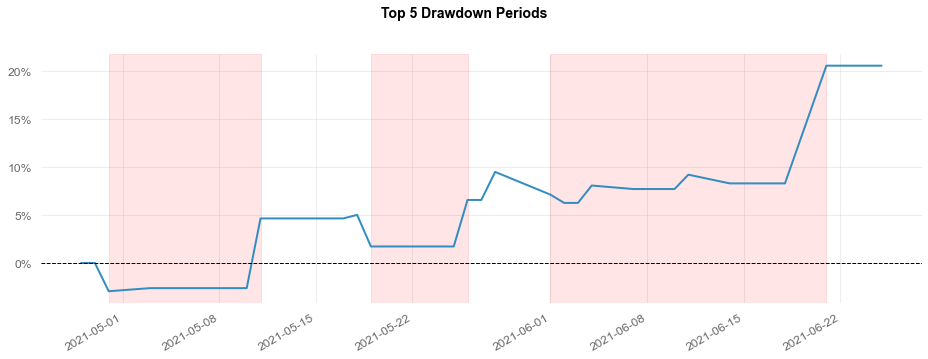

In [334]:
import quantstats as qs
# qs.plots.returns(stock, ylabel=False, lw=2, subtitle=False, figsize=(13, 5))
qs.plots.drawdowns_periods(
    stock, ylabel=False, lw=2, subtitle=False, figsize=(13, 5), compounded=False)
# qs.reports.metrics(stock, mode="base", compounded=True)
# qs.reports.plots(stock, mode="full", figsize=(10, 5), compounded=True)
# qs.reports.html(stock, "SPY", output="res.html", compounded=False)


In [335]:
# ##########################################
# # ДАННЫЕ EXANTE
#
# md_source = "EXANTE"
#
# # path = f"{base_path}/live-EUR:CHF.E.FX-quotes-60.jsonl"
# path = f"{base_path}/forex/live-EUR:CHF.E.FX-quotes-60-small-1.jsonl"
#
# md = pd.read_json(path, orient='records', lines=True)
# # md.columns = ["timestamp", "Open", "High", "Low", "Close"]
# md = md.rename(columns={"open": 'Open', 'high': 'High', "low": "Low", "close": "Close"})
# md = md.set_index('timestamp').sort_index()
# ohlc_dict = {'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last'}
# md = md.resample('15T').apply(ohlc_dict).dropna()
# md.index = md.index.tz_localize("UTC")
#
# # md.query('timestamp >= "2021-05-10 03:00:00+00"', inplace=True)
# # md.query('timestamp <= "2021-05-15 15:00:00+00"', inplace=True)
#
# print(md.head(5))
# print(md.tail(5))
